In [1]:
import yfinance as yf
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping
from prophet import Prophet
import itertools
import seaborn as sns
import time
import re
import string
import chardet
import html

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
azienda = yf.Ticker('TSLA')
dati_storici = azienda.history(period="max")
# Rendi l'indice (Date) timezone-unaware (senza fuso orario)
if isinstance(dati_storici.index, pd.DatetimeIndex):
    dati_storici.index = dati_storici.index.tz_localize(None)
# Salva i dati storici in un file Excel
filename = "tesla_dati_storici.xlsx"  
dati_storici.to_excel(filename)

In [7]:
df_a = pd.read_excel('tesla_dati_storici.xlsx')
# Converti la colonna 'Date' in formato datetime
df_a['Date'] = pd.to_datetime(df_a['Date'])
print(df_a.head())
print(df_a.tail())

        Date      Open      High       Low     Close     Volume  Dividends  \
0 2010-06-29  1.266667  1.666667  1.169333  1.592667  281494500          0   
1 2010-06-30  1.719333  2.028000  1.553333  1.588667  257806500          0   
2 2010-07-01  1.666667  1.728000  1.351333  1.464000  123282000          0   
3 2010-07-02  1.533333  1.540000  1.247333  1.280000   77097000          0   
4 2010-07-06  1.333333  1.333333  1.055333  1.074000  103003500          0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  
           Date        Open        High         Low       Close     Volume  \
3739 2025-05-09  290.209991  307.040009  290.000000  298.260010  132387800   
3740 2025-05-12  321.989990  322.209991  311.500000  318.380005  112826700   
3741 2025-05-13  320.000000  337.589996  316.799988  334.070007  136992600   
3742 2025-05-14  342.500000  350.000000  337.000000  347.679993  136997300   
3743 2025-05-15  340.339996  346.

In [8]:
#attività su dividendi e stock_split
# Crea copie temporanee per dividendi e stock split
dividendi = df_a[df_a['Dividends'] != 0].copy()
stock_split = df_a[df_a['Stock Splits'] != 0].copy()

# Visualizza le date e i valori di dividendi e stock split
print("Date dei dividendi:")
print(dividendi[['Date', 'Dividends']])

print("\nDate degli stock split:")
print(stock_split[['Date', 'Stock Splits']])

Date dei dividendi:
Empty DataFrame
Columns: [Date, Dividends]
Index: []

Date degli stock split:
           Date  Stock Splits
2561 2020-08-31             5
3061 2022-08-25             3


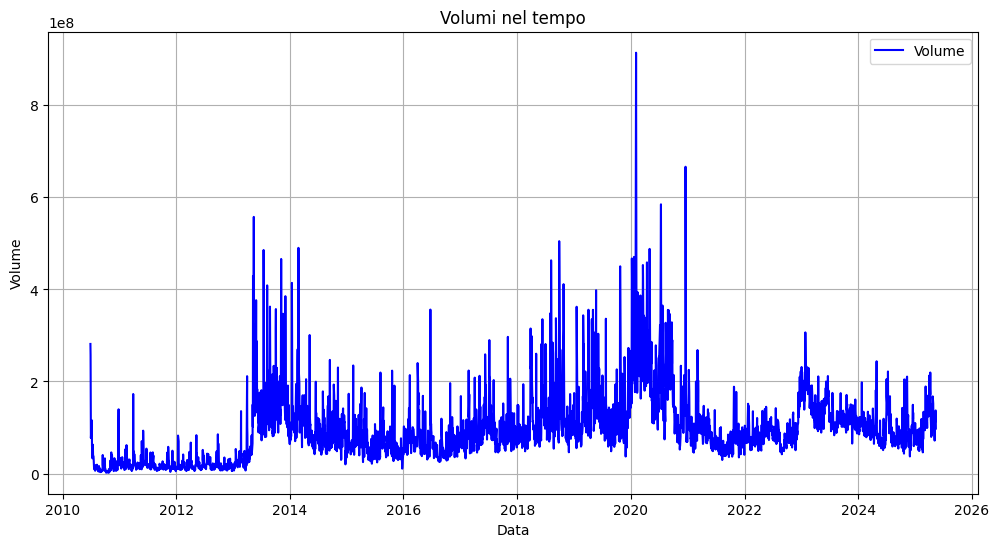

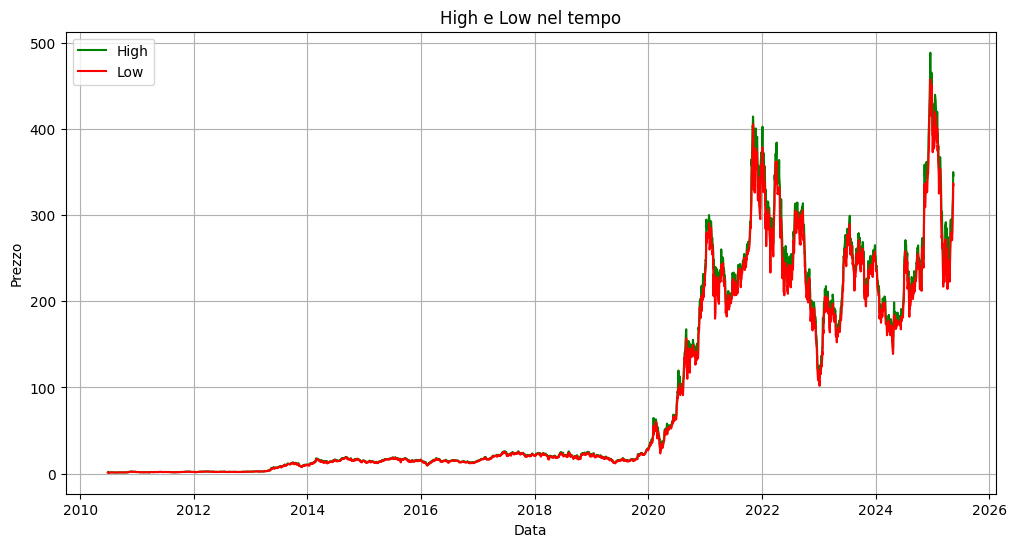

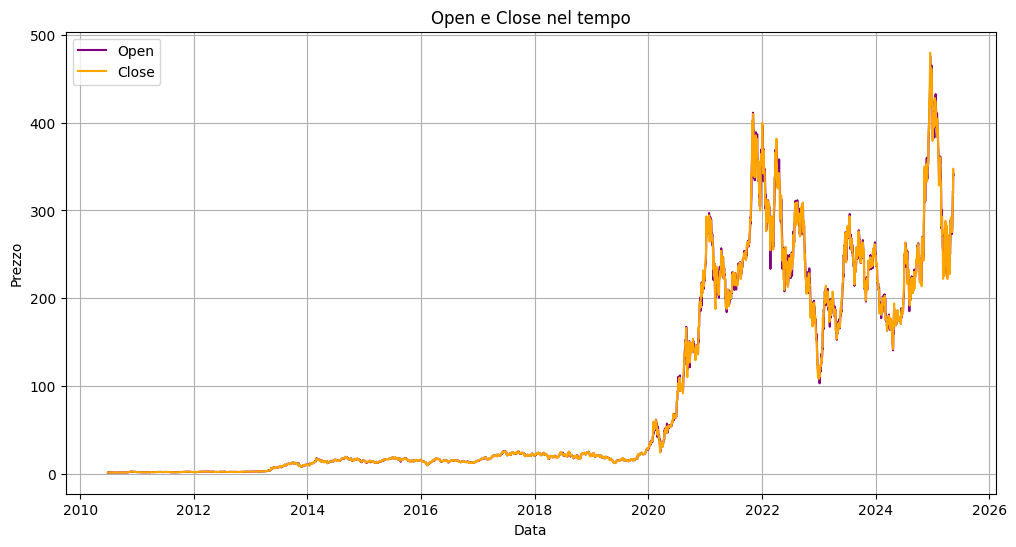

In [9]:
# 1. Grafico dei volumi
plt.figure(figsize=(12, 6))
plt.plot(df_a['Date'], df_a['Volume'], label='Volume', color='blue')
plt.title('Volumi nel tempo')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

# 2. Grafico High e Low
plt.figure(figsize=(12, 6))
plt.plot(df_a['Date'], df_a['High'], label='High', color='green')
plt.plot(df_a['Date'], df_a['Low'], label='Low', color='red')
plt.title('High e Low nel tempo')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

# 3. Grafico Open e Close
plt.figure(figsize=(12, 6))
plt.plot(df_a['Date'], df_a['Open'], label='Open', color='purple')
plt.plot(df_a['Date'], df_a['Close'], label='Close', color='orange')
plt.title('Open e Close nel tempo')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
#dati originali
# Esegui il test ADF
lista= ["Open", "Close", "Volume"]
for i in lista:
    adf_test = adfuller(df_a[i])

    # Estrai i risultati
    statistic = adf_test[0]
    pvalue = adf_test[1]
    critical_values = adf_test[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -1.1630287896941196
P-value: 0.6892942657401228
Valori critici: {'1%': -3.432109564216738, '5%': -2.8623174781858136, '10%': -2.567183862680981}
non stazionario
ADF test Close
Statistica ADF: -1.057398049949727
P-value: 0.7317587881538908
Valori critici: {'1%': -3.4321109857306853, '5%': -2.8623181061078666, '10%': -2.5671841969645706}
non stazionario
ADF test Volume
Statistica ADF: -3.8953014220008537
P-value: 0.00206969945611041
Valori critici: {'1%': -3.4321109857306853, '5%': -2.8623181061078666, '10%': -2.5671841969645706}
stazionario


In [10]:
#trasformazione logaritmica
# Crea una copia di df_a
df_a_log = df_a.copy()

# Colonne numeriche da trasformare (escludi 'Date' e colonne non numeriche)
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Applica la trasformazione logaritmica alle colonne numeriche
for col in numeric_cols:
    # Aggiungi una piccola costante per evitare logaritmi di zero o valori negativi
    df_a_log[col] = np.log(df_a_log[col])
# Visualizza le prime righe di df_a_log
print(df_a_log.head())

        Date      Open      High       Low     Close     Volume  Dividends  \
0 2010-06-29  0.236389  0.510826  0.156433  0.465410  19.455623          0   
1 2010-06-30  0.541936  0.707050  0.440403  0.462895  19.367720          0   
2 2010-07-01  0.510826  0.546965  0.301092  0.381172  18.629985          0   
3 2010-07-02  0.427444  0.431782  0.221008  0.246860  18.160575          0   
4 2010-07-06  0.287682  0.287682  0.053856  0.071390  18.450274          0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  


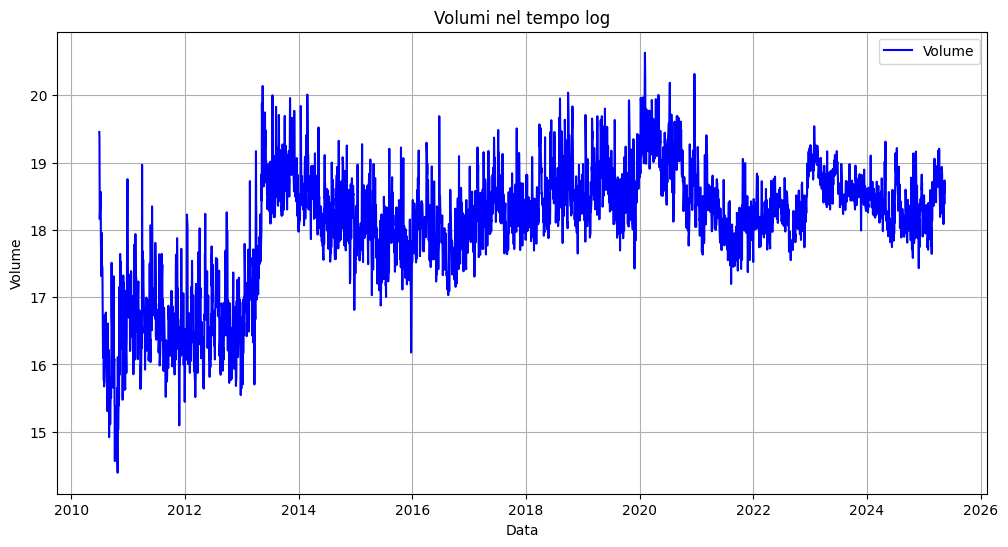

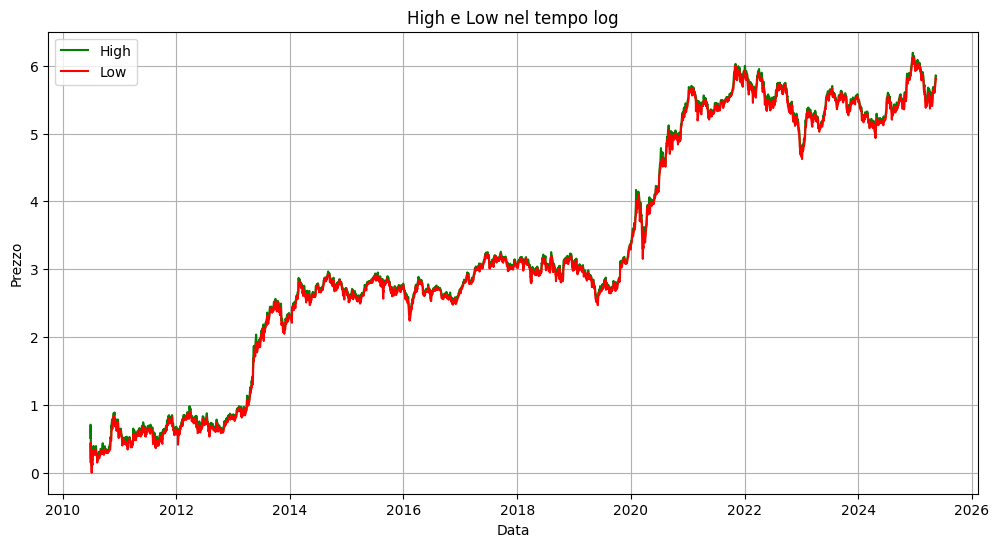

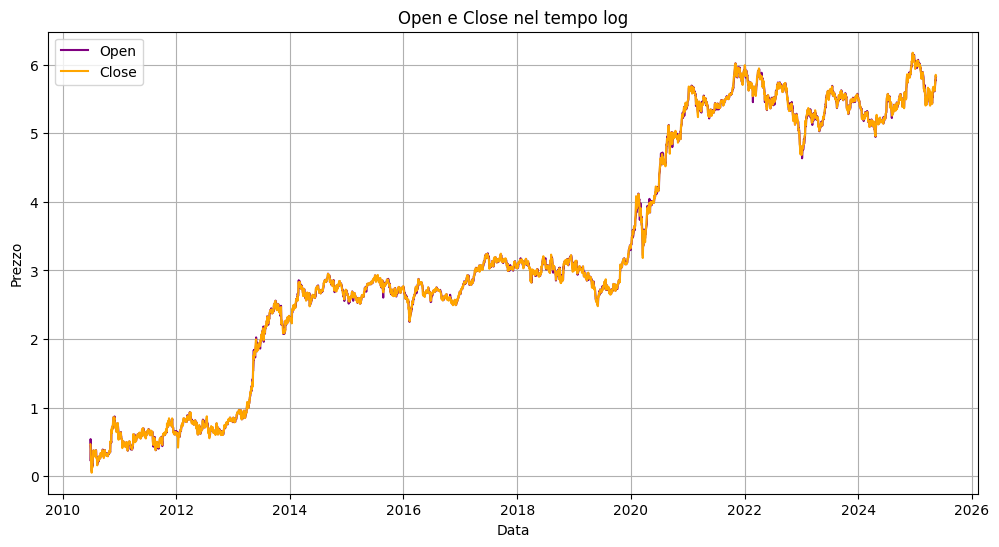

In [11]:
# 1. Grafico dei volumi
plt.figure(figsize=(12, 6))
plt.plot(df_a_log['Date'], df_a_log['Volume'], label='Volume', color='blue')
plt.title('Volumi nel tempo log')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

# 2. Grafico High e Low
plt.figure(figsize=(12, 6))
plt.plot(df_a_log['Date'], df_a_log['High'], label='High', color='green')
plt.plot(df_a_log['Date'], df_a_log['Low'], label='Low', color='red')
plt.title('High e Low nel tempo log')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

# 3. Grafico Open e Close
plt.figure(figsize=(12, 6))
plt.plot(df_a_log['Date'], df_a_log['Open'], label='Open', color='purple')
plt.plot(df_a_log['Date'], df_a_log['Close'], label='Close', color='orange')
plt.title('Open e Close nel tempo log')
plt.xlabel('Data')
plt.ylabel('Prezzo')
plt.grid(True)
plt.legend()
plt.show()

       Open      High       Low     Close       Date
0       NaN       NaN       NaN       NaN 2010-06-29
1  0.357368  0.216800  0.328392 -0.002511 2010-06-30
2 -0.030632 -0.147929 -0.130043 -0.078473 2010-07-01
3 -0.080000 -0.108796 -0.076961 -0.125683 2010-07-02
4 -0.130435 -0.134199 -0.153928 -0.160937 2010-07-06


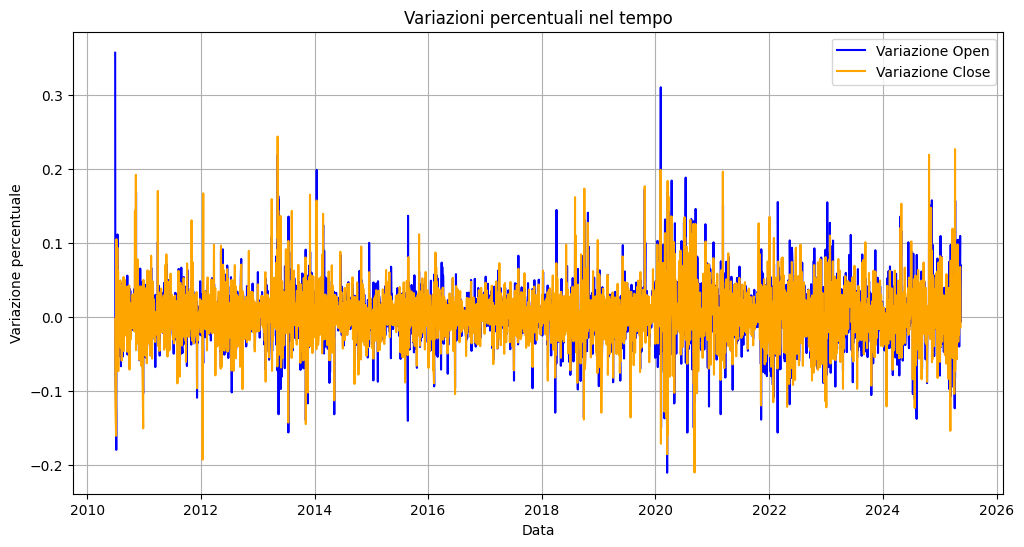

In [12]:
# Calcola le variazioni percentuali sui dati originali
variations_a = df_a[['Open', 'High', 'Low', 'Close']].pct_change()

# Aggiungi la colonna 'Date' al DataFrame delle variazioni
variations_a['Date'] = df_a['Date']

# Visualizza le prime righe del DataFrame delle variazioni
print(variations_a.head())

# Plot delle variazioni
plt.figure(figsize=(12, 6))
plt.plot(variations_a['Date'], variations_a['Open'], label='Variazione Open', color='blue')
plt.plot(variations_a['Date'], variations_a['Close'], label='Variazione Close', color='orange')
plt.title('Variazioni percentuali nel tempo')
plt.xlabel('Data')
plt.ylabel('Variazione percentuale')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
#dati log
# Esegui il test ADF
lista= ["Open", "Close", "Volume"]
for i in lista:
    adf_test_log = adfuller(df_a_log[i])

    # Estrai i risultati
    statistic = adf_test_log[0]
    pvalue = adf_test_log[1]
    critical_values = adf_test_log[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -0.757481435304104
P-value: 0.8312937487481765
Valori critici: {'1%': -3.432098741718118, '5%': -2.8623126975788264, '10%': -2.5671813176558236}
non stazionario
ADF test Close
Statistica ADF: -0.8008817771420456
P-value: 0.8188629150375392
Valori critici: {'1%': -3.4320982741938835, '5%': -2.8623124910596176, '10%': -2.567181207712407}
non stazionario
ADF test Volume
Statistica ADF: -2.7050895651373694
P-value: 0.073161685288094
Valori critici: {'1%': -3.4321109857306853, '5%': -2.8623181061078666, '10%': -2.5671841969645706}
non stazionario


In [15]:
# Applica la differenziazione
df_a_trasf = df_a_log.diff().dropna()
#ADF sui dati trasformati
for i in lista:
    adf_test_trasf = adfuller(df_a_trasf[i])

    # Estrai i risultati
    statistic = adf_test_trasf[0]
    pvalue = adf_test_trasf[1]
    critical_values = adf_test_trasf[4]

    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Open
Statistica ADF: -63.50853087434654
P-value: 0.0
Valori critici: {'1%': -3.432098741718118, '5%': -2.8623126975788264, '10%': -2.5671813176558236}
stazionario
ADF test Close
Statistica ADF: -61.223680805797734
P-value: 0.0
Valori critici: {'1%': -3.432098741718118, '5%': -2.8623126975788264, '10%': -2.5671813176558236}
stazionario
ADF test Volume
Statistica ADF: -18.459625017276167
P-value: 2.147715218920112e-30
Valori critici: {'1%': -3.4321109857306853, '5%': -2.8623181061078666, '10%': -2.5671841969645706}
stazionario


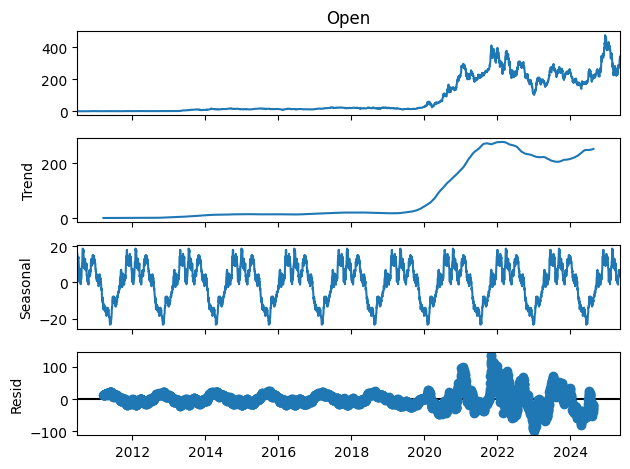

Statistica ADF sui residui: -6.58110852720433
P-value: 7.510416391340267e-09
Valori critici: {'1%': -3.4323006141089776, '5%': -2.86240186752734, '10%': -2.567228789048532}
stazionario


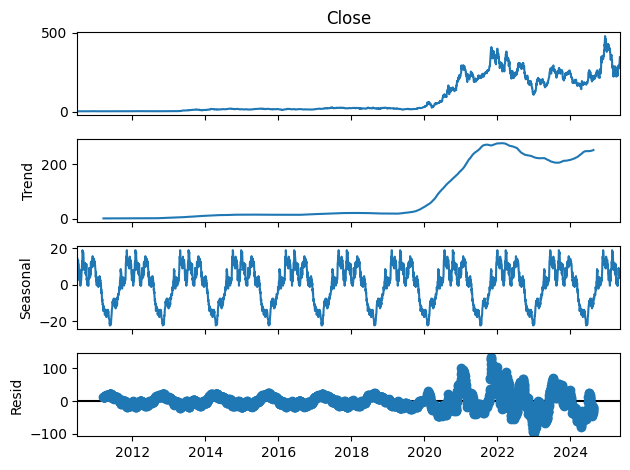

Statistica ADF sui residui: -6.343646332975297
P-value: 2.716138799506921e-08
Valori critici: {'1%': -3.4323035277087404, '5%': -2.862403154462218, '10%': -2.567229474181332}
stazionario


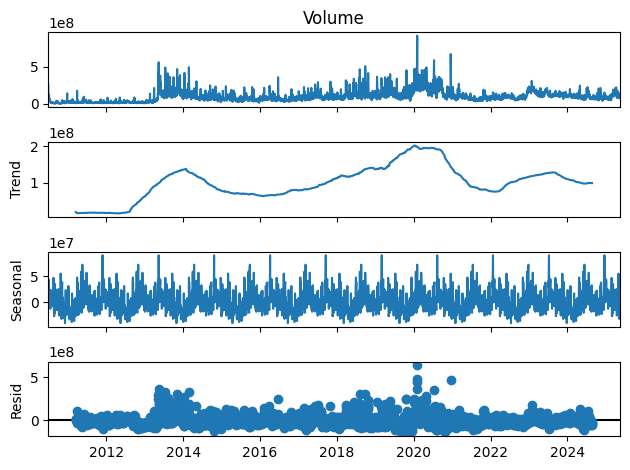

Statistica ADF sui residui: -6.8326197070734604
P-value: 1.8768699053920483e-09
Valori critici: {'1%': -3.4323023612249797, '5%': -2.8624026392273474, '10%': -2.5672291998828043}
stazionario


In [16]:
# Crea una copia di df_a
df_a_decomp = df_a.copy()

# Imposta la colonna 'Date' come indice
df_a_decomp.set_index('Date', inplace=True)

for i in lista:
    data = df_a_decomp[i]
    
    # Applica la decomposizione stagionale
    decomposition = seasonal_decompose(data, model='additive', period=365)  # Modifica il periodo se necessario
    
    # Visualizza la decomposizione
    decomposition.plot()
    plt.show()
    
    # Estrai i residui
    resid = decomposition.resid.dropna()
    
    # Esegui il test ADF sui residui
    adf_test = adfuller(resid)
    
    # Estrai i risultati
    statistic = adf_test[0]
    pvalue = adf_test[1]
    critical_values = adf_test[4]
    
    # Stampa i risultati
    print("Statistica ADF sui residui:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

In [17]:
#Metodi di Previsione con dataset stazionario
#preso i valori di close con operazione diff. e trasf. log. mentre i valori volume gli originali perhché già stazionari
data_a = pd.DataFrame({
    'Close': df_a_trasf['Close'],
    'Open': df_a_trasf['Open']
})
# Dividi i dati in train e test set
train_a, test_a = train_test_split(data_a, test_size=0.2, shuffle=False)

# Visualizza le dimensioni dei set
print("Dimensione train_a:", train_a.shape)
print("Dimensione test_a:", test_a.shape)

# Visualizza le prime righe dei set
print("\nTrain_a:")
print(train_a.head())
print(train_a.tail())

print("\nTest_a:")
print(test_a.head())
print(test_a.tail())

Dimensione train_a: (2994, 2)
Dimensione test_a: (749, 2)

Train_a:
      Close      Open
1 -0.002515  0.305547
2 -0.081723 -0.031111
3 -0.134312 -0.083382
4 -0.175470 -0.139762
5 -0.019431 -0.198451
         Close      Open
2990  0.055557  0.098392
2991 -0.060556 -0.008204
2992  0.050132 -0.026148
2993 -0.070437 -0.003807
2994 -0.000550 -0.051709

Test_a:
         Close      Open
2995 -0.066316  0.009838
2996  0.016433 -0.086203
2997 -0.071770 -0.002277
2998  0.047625 -0.046479
2999  0.071643  0.058479
         Close      Open
3739  0.046108  0.037137
3740  0.065280  0.103916
3741  0.048105 -0.006199
3742  0.039932  0.067951
3743 -0.014077 -0.006327


In [18]:
#verifica di valori 0 o infinito
print(data_a['Close'][data_a['Close'].isna()])
print(data_a['Close'][np.isinf(data_a['Close'])])  
print(data_a['Open'][data_a['Open'].isna()])
print(data_a['Open'][np.isinf(data_a['Open'])])

# Gestisci il valore NaN (esempio: imputazione con la media)
data_a['Close'] = data_a['Close'].fillna(data_a['Close'].mean())

# Verifica la correzione
print(data_a['Close'].isna().sum())
print(data_a['Close'].isin([np.inf, -np.inf]).sum())
print(data_a['Open'].isna().sum())
print(data_a['Open'].isin([np.inf, -np.inf]).sum())

Series([], Name: Close, dtype: float64)
Series([], Name: Close, dtype: float64)
Series([], Name: Open, dtype: float64)
Series([], Name: Open, dtype: float64)
0
0
0
0


In [19]:
lista1= ['Close', 'Open']
for i in lista1:
    adf_test_data_a = adfuller(data_a[i])
    
    # Estrai i risultati
    statistic = adf_test_data_a[0]
    pvalue = adf_test_data_a[1]
    critical_values = adf_test_data_a[4]
    
    # Stampa i risultati
    print (f"ADF test {i}")
    print("Statistica ADF:", statistic)
    print("P-value:", pvalue)
    print("Valori critici:", critical_values)
    if pvalue < 0.05:
        print ("stazionario")
    else:
        print ("non stazionario")

ADF test Close
Statistica ADF: -61.223680805797734
P-value: 0.0
Valori critici: {'1%': -3.432098741718118, '5%': -2.8623126975788264, '10%': -2.5671813176558236}
stazionario
ADF test Open
Statistica ADF: -63.50853087434654
P-value: 0.0
Valori critici: {'1%': -3.432098741718118, '5%': -2.8623126975788264, '10%': -2.5671813176558236}
stazionario


Close


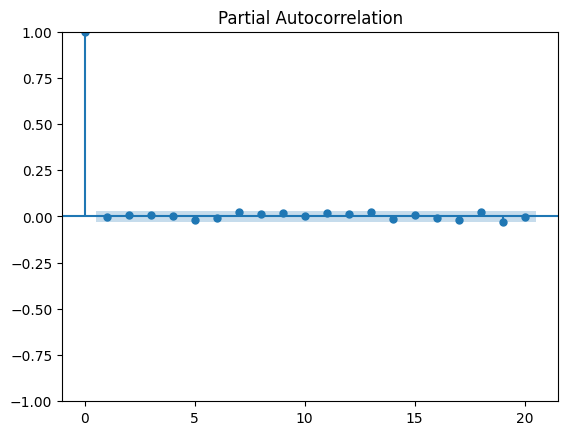

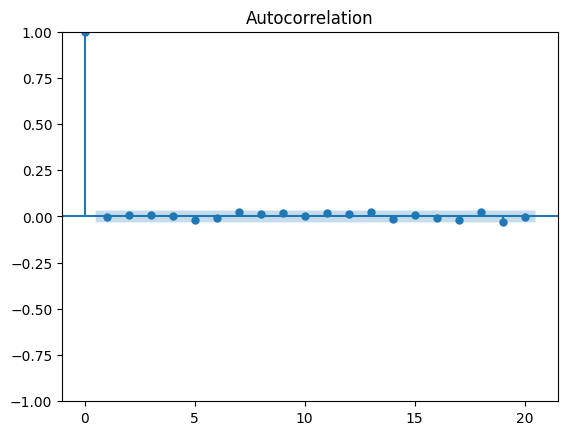

Open


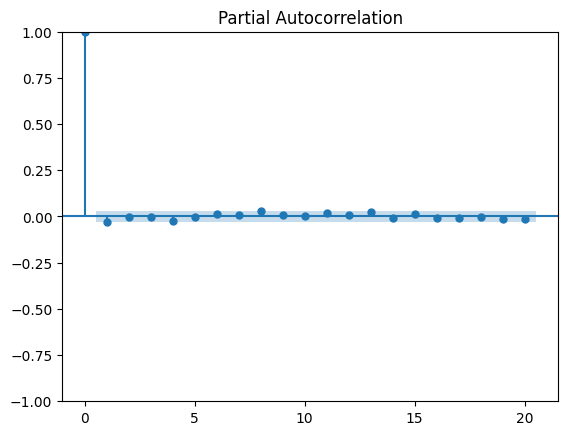

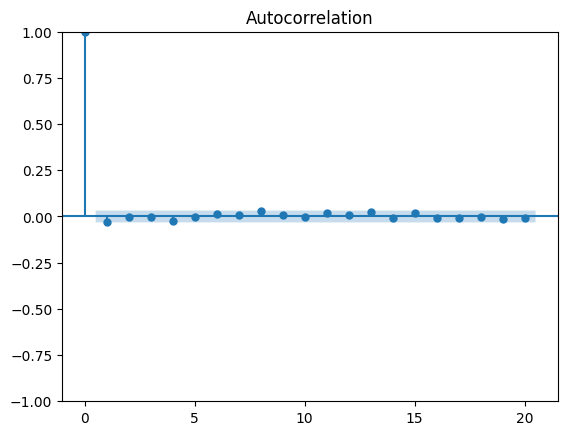

In [20]:
for campo in data_a:
    print (campo)
    plot_pacf(data_a[campo], lags=20)
    plt.show()
    plot_acf(data_a[campo], lags=20)
    plt.show()

In [21]:
def calcola_metriche(y_true, y_pred):
    # Rimuovi i valori NaN
    y_true = y_true.dropna()
    y_pred = y_pred.dropna()
    # Allinea gli indici per garantire che y_true e y_pred abbiano la stessa lunghezza
    y_true, y_pred = y_true.align(y_pred, join='inner')
    me = np.mean(y_pred - y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mpe = np.mean((y_true - y_pred) / y_true) * 100
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return me, rmse, mae, mpe, mape

In [22]:
def modello_arima(train,test,p,d,q):
    modello_arima = ARIMA(train, order=(p, d, q))
    risultati_arima = modello_arima.fit()
    # Effettua le previsioni sul set di train
    previsioni_train_arima = risultati_arima.predict(start=0, end=len(train) - 1)
    # Effettua le previsioni sul set di test
    previsioni_test_arima = risultati_arima.predict(start=len(train), end=len(train) + len(test) - 1)
    me_train, rmse_train, mae_train, mpe_train, mape_train = calcola_metriche(train, previsioni_train_arima)
    print('Valutazione train')
    print(f"ME: {me_train}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    me_test, rmse_test, mae_test, mpe_test, mape_test = calcola_metriche(test, previsioni_test_arima)
    print('Valutazione test')
    print(f"ME: {me_test}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")
    # Visualizza le previsioni rispetto ai dati reali
    plt.figure(figsize=(12, 6))
    plt.plot(train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(train.index, previsioni_train_arima, label='Previsioni Train', color='red')
    plt.plot(test.index, previsioni_test_arima, label='Previsioni Test', color='green')
    plt.legend()
    plt.title('Previsioni ARIMA')
    plt.show()
    return risultati_arima

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Valutazione train
ME: -4.494005192069212e-06, RMSE: 0.035583938650673184, MAE: 0.02440970123290671, MPE: -inf, MAPE: inf
Valutazione test
ME: 0.0011492078753720745, RMSE: 0.039489023254230426, MAE: 0.0289582227116673, MPE: -inf, MAPE: inf


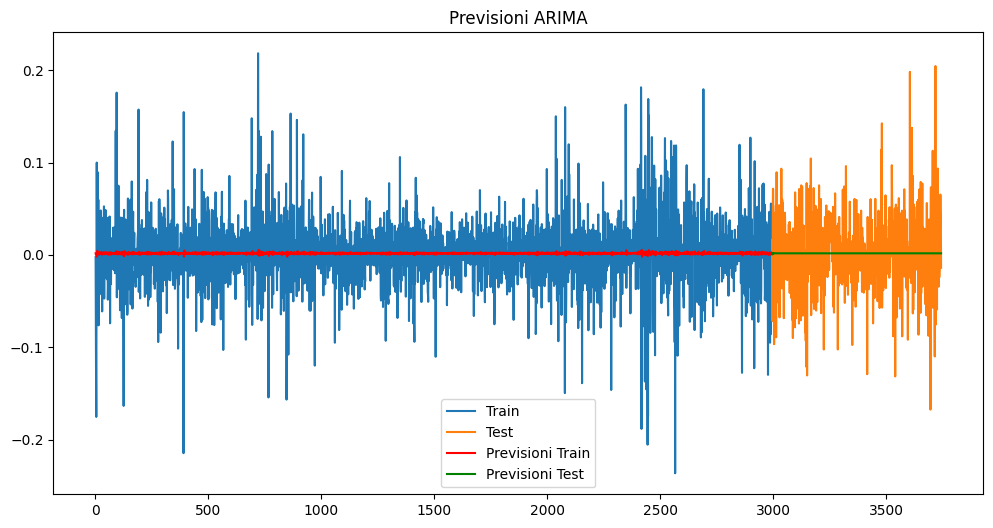

C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Valutazione train
ME: -7.539094707985496e-06, RMSE: 0.036914158893914334, MAE: 0.025358765326770984, MPE: -inf, MAPE: inf
Valutazione test
ME: 0.0012401805086902406, RMSE: 0.040765329679691174, MAE: 0.030700743649367434, MPE: -inf, MAPE: inf


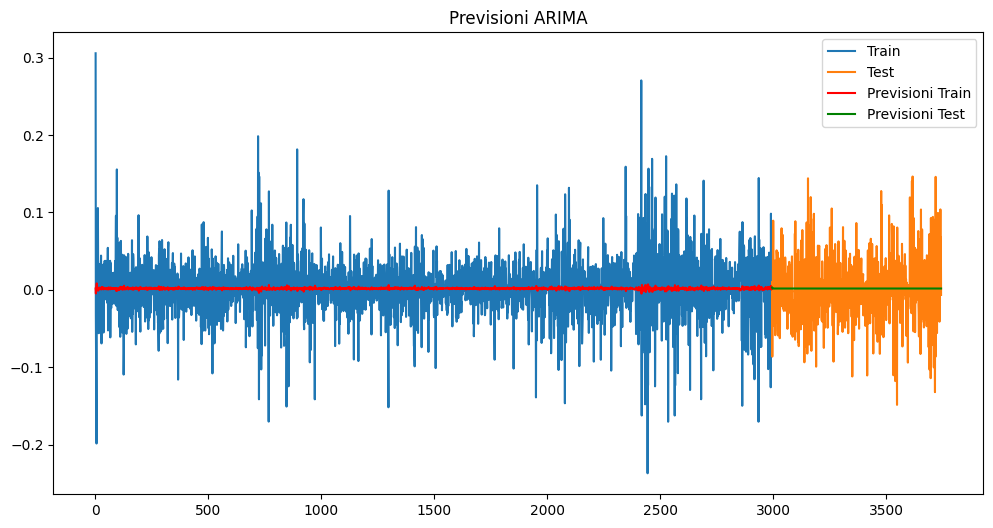

In [23]:
modello_arima(train_a['Close'], test_a['Close'], 4, 0, 4)
modello_arima(train_a['Open'], test_a['Open'], 2, 0, 1)

In [24]:
#arima iterativo
def modello_arima_iterativo(train, test, p_range, d_range, q_range):
    miglior_rmse = float('inf')
    miglior_modello = None
    migliori_parametri = None
    pdq = list(itertools.product(p_range, d_range, q_range))

    print(pdq)

    for param in pdq:
        rmse_test = None
        try:
            modello_arima = ARIMA(train, order=param)
            risultati_arima = modello_arima.fit()
            previsioni_test_arima = risultati_arima.predict(start=len(train), end=len(train) + len(test) - 1)
            rmse_test = mean_squared_error(test, previsioni_test_arima, squared=False)

            if rmse_test < miglior_rmse:
                miglior_rmse = rmse_test
                miglior_modello = risultati_arima
                migliori_parametri = param

        except:
            pass

        print(f"Parametri: {param}, RMSE: {rmse_test}")

    print(f"Migliori parametri: {migliori_parametri}")
    print(f"Miglior RMSE: {miglior_rmse}")

    # Visualizza le previsioni del miglior modello (se trovato)
    if miglior_modello is not None:
        previsioni_train_arima = miglior_modello.predict(start=0, end=len(train) - 1)
        previsioni_test_arima = miglior_modello.predict(start=len(train), end=len(train) + len(test) - 1)
    else:
        previsioni_train_arima = np.zeros(len(train)) # Inizializza con zeri
        previsioni_test_arima = np.zeros(len(test)) # Inizializza con zeri

    plt.figure(figsize=(12, 6))
    plt.plot(train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(train.index, previsioni_train_arima, label='Previsioni Train', color='red')
    plt.plot(test.index, previsioni_test_arima, label='Previsioni Test', color='green')
    plt.legend()
    plt.title('Previsioni ARIMA')
    plt.show()

    return miglior_modello

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3)]


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (0, 0, 0), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (0, 0, 1), RMSE: None


...

Parametri: (3, 2, 1), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Parametri: (3, 2, 2), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (3, 2, 3), RMSE: None
Migliori parametri: None
Miglior RMSE: inf


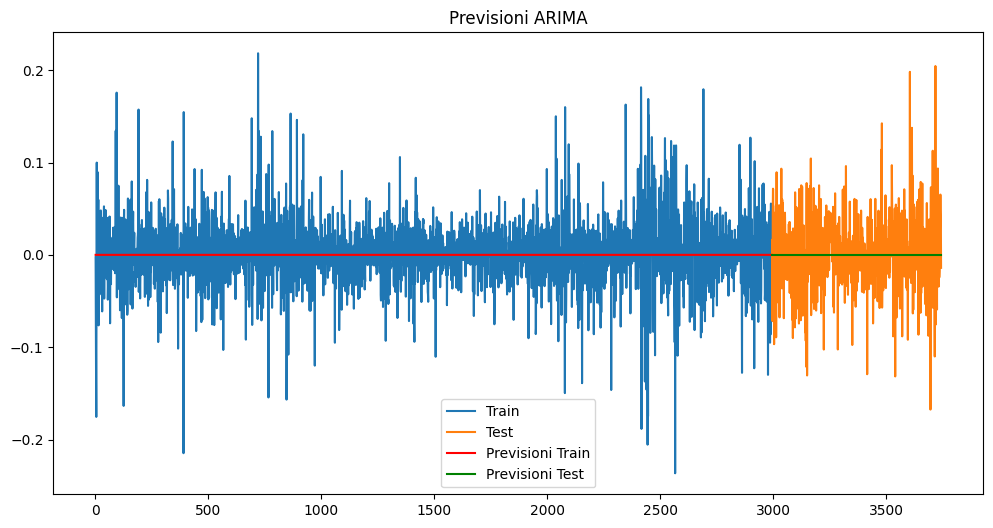

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3)]


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIE

Parametri: (0, 0, 0), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (0, 0, 1), RMSE: None


...

Parametri: (3, 2, 1), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmod

Parametri: (3, 2, 2), RMSE: None


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Parametri: (3, 2, 3), RMSE: None
Migliori parametri: None
Miglior RMSE: inf


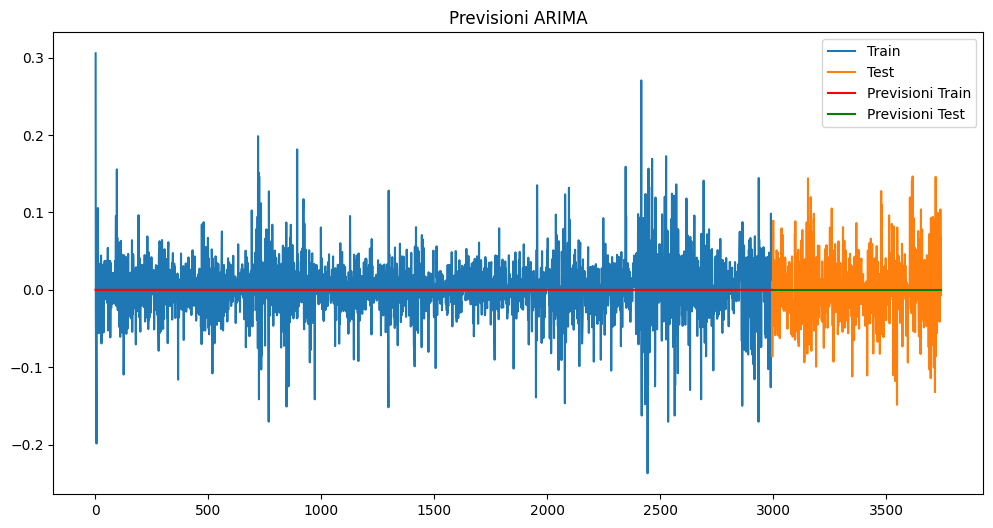

In [25]:
p_range = range(0, 4)
d_range = range(0, 3)
q_range = range(0, 4)

miglior_modello = modello_arima_iterativo(train_a['Close'], test_a['Close'], p_range, d_range, q_range)
miglior_modello = modello_arima_iterativo(train_a['Open'], test_a['Open'], p_range, d_range, q_range)

In [26]:
#Modello Prophet
#preparazione del dataset per prophet 
data_a_prophet = pd.DataFrame({
    'ds': df_a['Date'],
    'Close': df_a_trasf['Close'],
    'Open': df_a_trasf['Open']
})
data_a_prophet['ds'] = pd.to_datetime(data_a_prophet['ds'])
# Gestisci il valore NaN (esempio: imputazione con la media)
data_a_prophet['Close'] = data_a_prophet['Close'].fillna(data_a['Close'].mean())
data_a_prophet['Open'] = data_a_prophet['Close'].fillna(data_a['Open'].mean())
# Dividi i dati in train e test set
train_a_prophet, test_a_prophet = train_test_split(data_a_prophet, test_size=0.2, shuffle=False)
train_a_prophet.head

<bound method NDFrame.head of              ds     Close      Open
0    2010-06-29  0.001435  0.001435
1    2010-06-30 -0.002515 -0.002515
2    2010-07-01 -0.081723 -0.081723
3    2010-07-02 -0.134312 -0.134312
4    2010-07-06 -0.175470 -0.175470
...         ...       ...       ...
2990 2022-05-13  0.055557  0.055557
2991 2022-05-16 -0.060556 -0.060556
2992 2022-05-17  0.050132  0.050132
2993 2022-05-18 -0.070437 -0.070437
2994 2022-05-19 -0.000550 -0.000550

[2995 rows x 3 columns]>

In [27]:
#preparazione del train e test
# Preparazione dei dati per Prophet (Close)
train_close = train_a_prophet[['ds', 'Close']].rename(columns={'Close': 'y'})
test_close = test_a_prophet[['ds', 'Close']].rename(columns={'Close': 'y'})

# Preparazione dei dati per Prophet (Volume)
train_open = train_a_prophet[['ds', 'Open']].rename(columns={'Open': 'y'})
test_open = test_a_prophet[['ds', 'Open']].rename(columns={'Open': 'y'})

In [28]:
def modello_prophet(train,test):
    # Identifica e gestisci i valori nan nel train set
    train_nan_mask = train['y'].isna()
    train = train[~train_nan_mask]

    # Identifica e gestisci i valori nan nel test set
    test_nan_mask = test['y'].isna()
    test = test[~test_nan_mask]

    # Crea un modello Prophet
    model = Prophet(changepoint_prior_scale=0.01) # Valore più basso per ridurre l'overfitting

    # Addestra il modello sui dati di training
    model.fit(train)

    # Effettua le previsioni sul set di training
    forecast_train = model.predict(train)

    # Effettua le previsioni sul set di test
    forecast_test = model.predict(test)

    # Rimuovi i valori nan dalle previsioni e allinea gli indici
    forecast_test_nan_mask = forecast_test['yhat'].isna()
    forecast_test = forecast_test[~forecast_test_nan_mask].reset_index(drop=True) # Reset index
    test = test.reset_index(drop=True)[~forecast_test_nan_mask.reset_index(drop=True)] # reset and align index

    # Calcola le metriche di valutazione sul set di training
    me_train = np.mean(train['y'] - forecast_train['yhat'])
    rmse_train = np.sqrt(mean_squared_error(train['y'], forecast_train['yhat']))
    mae_train = np.mean(np.abs(train['y'] - forecast_train['yhat']))
    mpe_train = np.mean((train['y'] - forecast_train['yhat']) / train['y']) * 100
    mape_train = np.mean(np.abs((train['y'] - forecast_train['yhat']) / train['y'])) * 100

    # Calcola le metriche di valutazione sul set di test
    me_test = np.mean(test['y'] - forecast_test['yhat'])
    rmse_test = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
    mae_test = np.mean(np.abs(test['y'] - forecast_test['yhat']))
    mpe_test = np.mean((test['y'] - forecast_test['yhat']) / test['y']) * 100
    mape_test = np.mean(np.abs((test['y'] - forecast_test['yhat']) / test['y'])) * 100

    # Stampa le metriche di valutazione
    print('Valutazione train')
    print(f'ME: {me_train}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}')

    print('Valutazione test')
    print(f'ME: {me_test}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}')

    # Visualizza le previsioni rispetto ai valori reali
    plt.plot(train['ds'], train['y'], label='Train')
    plt.plot(test['ds'], test['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predictions')
    plt.legend()
    plt.show()

    # Visualizza i componenti del modello
    model.plot_components(forecast_test)
    plt.show()

    return model

Open


11:35:25 - cmdstanpy - INFO - Chain [1] start processing
11:35:27 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Valutazione train
ME: -9.439009102373111e-05, RMSE: 0.03544006488159734, MAE: 0.024374907281893936, MPE: nan, MAPE: inf
Valutazione test
ME: -0.0015986459234048343, RMSE: 0.03946745537407611, MAE: 0.029052896381891482, MPE: -inf, MAPE: inf


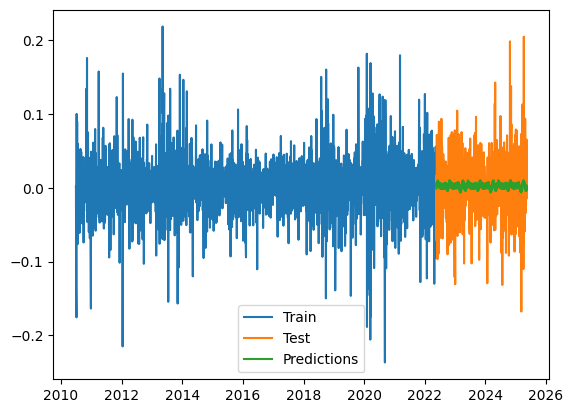

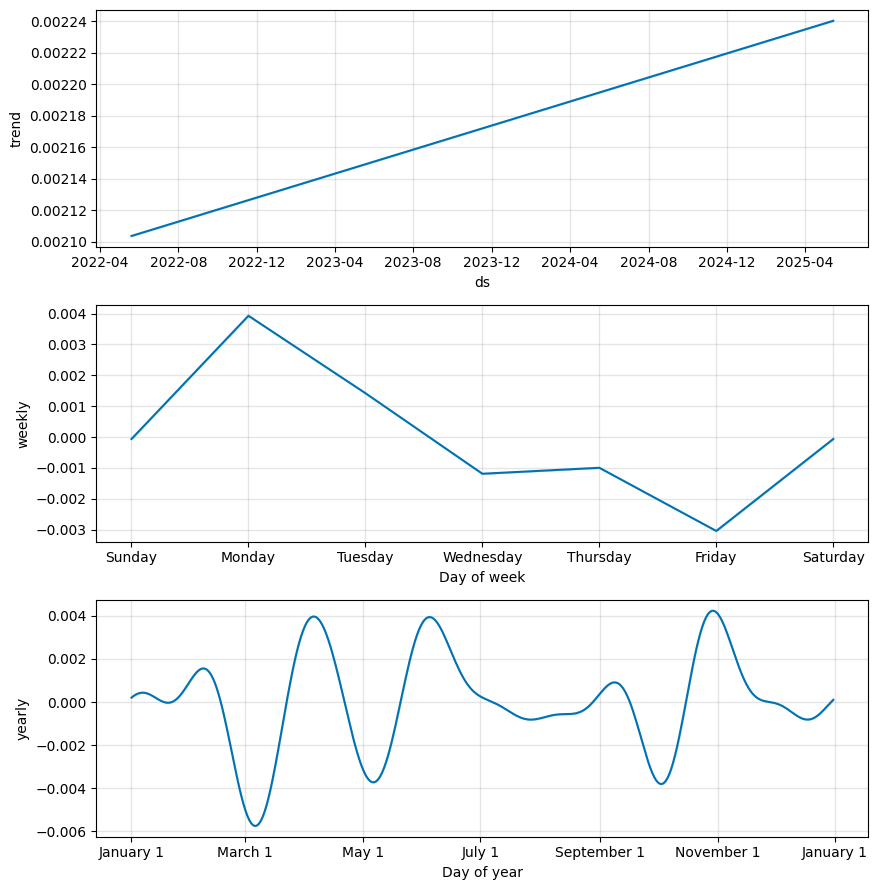

Close


11:35:32 - cmdstanpy - INFO - Chain [1] start processing
11:35:32 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Valutazione train
ME: -9.439009102373111e-05, RMSE: 0.03544006488159734, MAE: 0.024374907281893936, MPE: nan, MAPE: inf
Valutazione test
ME: -0.0015986459234048343, RMSE: 0.03946745537407611, MAE: 0.029052896381891482, MPE: -inf, MAPE: inf


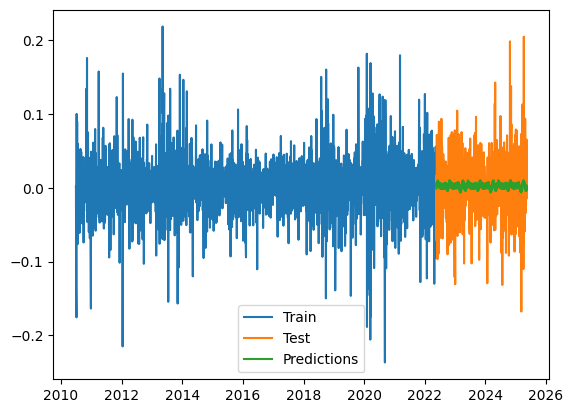

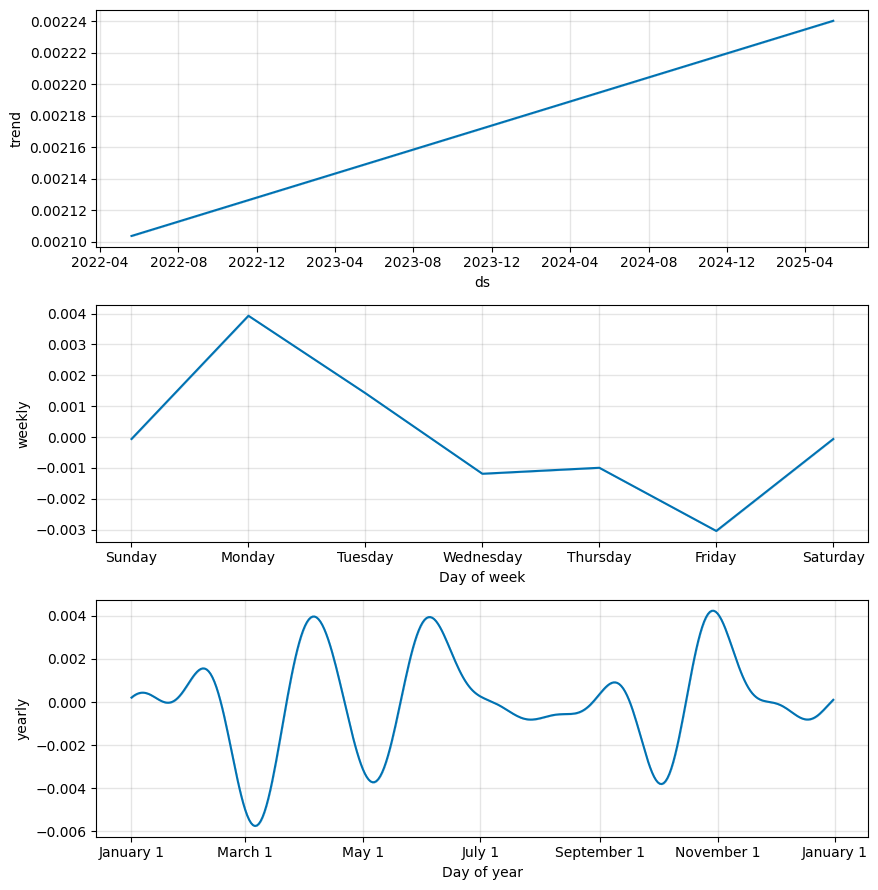

In [29]:
print ('Open')
# Applica il metodo a train_volume e test_volume
model_open = modello_prophet(train_open, test_open)

print ('Close')
# Applica il metodo a train_close e test_close
model_close = modello_prophet(train_close, test_close)

In [30]:
# Metodi con dataset non stazionario
# Preparazione del dataset usato dati log. per problemi di differenza di distribuzione dei dati tra train e test
close_data = df_a_log['Close'].values.reshape(-1, 1)
open_data = df_a_log['Open'].values.reshape(-1, 1)
#divisione train e test
train_a_rnn_close, test_a_rnn_close = train_test_split(close_data, test_size=0.2, shuffle=False)
train_a_rnn_open, test_a_rnn_open = train_test_split(open_data, test_size=0.2, shuffle=False)
print (train_a_rnn_close)

[[0.46540996]
 [0.46289532]
 [0.38117241]
 ...
 [5.53682231]
 [5.46638504]
 [5.46583542]]


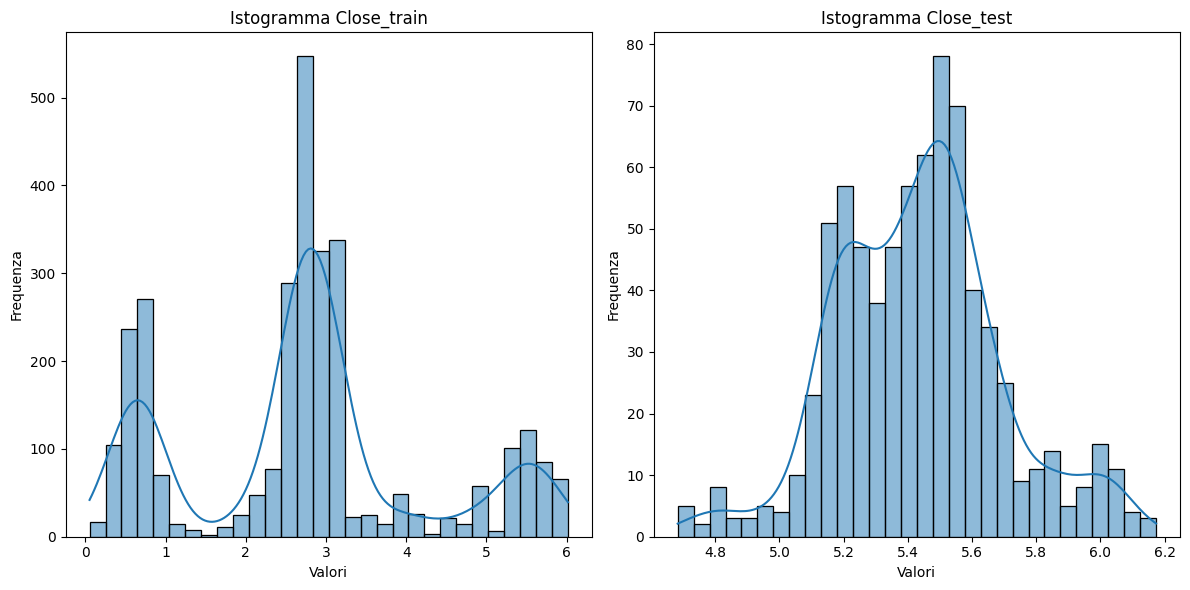

In [31]:
# Crea il istogrammi
# Appiattisci l'array in un array unidimensionale
train_a_rnn_close_flat = train_a_rnn_close.flatten()
df = pd.DataFrame({'valori': train_a_rnn_close_flat})

# Appiattisci l'array in un array unidimensionale
test_a_rnn_close_flat = test_a_rnn_close.flatten()
df_t = pd.DataFrame({'valori': test_a_rnn_close_flat,})


# Crea gli istogrammi
plt.figure(figsize=(12, 6))  # Imposta la dimensione della figura

plt.subplot(1, 2, 1)  # Crea il primo subplot (1 riga, 2 colonne, posizione 1)
sns.histplot(train_a_rnn_close_flat, bins=30, kde=True)
plt.title('Istogramma Close_train')
plt.xlabel('Valori')
plt.ylabel('Frequenza')

plt.subplot(1, 2, 2)  # Crea il secondo subplot (1 riga, 2 colonne, posizione 2)
sns.histplot(test_a_rnn_close_flat, bins=30, kde=True)
plt.title('Istogramma Close_test')
plt.xlabel('Valori')
plt.ylabel('Frequenza')

plt.tight_layout()  # Aggiusta la spaziatura tra i subplot
plt.show()

In [32]:
#RNN
def modello_rnn(train, test, seq_length=10, epochs=100, learning_rate=0.001, dropout_rate=0.3, l2_rate=0.01):
    # 1. Preparazione dei dati
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.reshape(-1, 1)) 
    scaled_test = scaler.transform(test.reshape(-1, 1))

    def create_sequences(data, seq_length):
        xs = []
        ys = []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(scaled_train, seq_length)
    X_test, y_test = create_sequences(scaled_test, seq_length)

    # 2. Costruzione e addestramento del modello RNN
    model = Sequential()
    model.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(l2_rate)))  # Solo L2 a LSTM
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_rate)))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    # Aggiungi EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # Configura EarlyStopping
    history = model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0) 
    # 3. Effettua le previsioni
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Inverti la scala delle previsioni
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)

    # 5. Calcola le metriche di valutazione
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
    mpe_train = np.mean((y_train_original - y_train_pred_original) / y_train_original) * 100
    mape_train = np.mean(np.abs((y_train_original - y_train_pred_original) / y_train_original)) * 100

    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
    mpe_test = np.mean((y_test_original - y_test_pred_original) / y_test_original) * 100
    mape_test = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100

    # 6. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"ME: {np.mean(y_train_original - y_train_pred_original)}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    print("Valutazione test")
    print(f"ME: {np.mean(y_test_original - y_test_pred_original)}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")

    # 7. Visualizza le previsioni
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train)), train, label='Train')
    plt.plot(range(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(range(len(train) + seq_length, len(train) + len(test)), y_test_pred_original, label='Predictions') 
    plt.legend()
    plt.show()

    return model, history

CLose


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step   
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Valutazione train
ME: 0.26969928613515765, RMSE: 0.4525129289533108, MAE: 0.28316689796632305, MPE: 8.044369190461639, MAPE: 9.975544797577156
Valutazione test
ME: 1.027149899420023, RMSE: 1.039367842624494, MAE: 1.027149899420023, MPE: 18.819558219739115, MAPE: 18.819558219739115


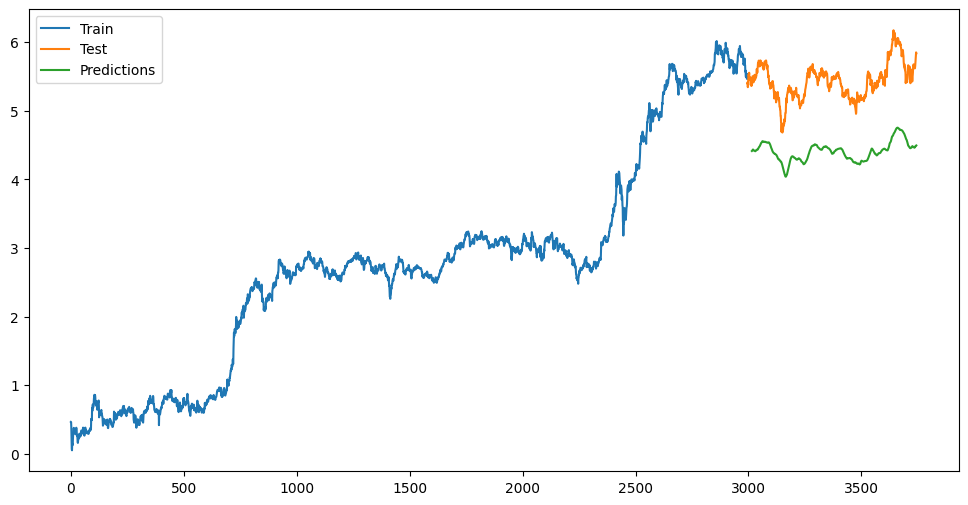

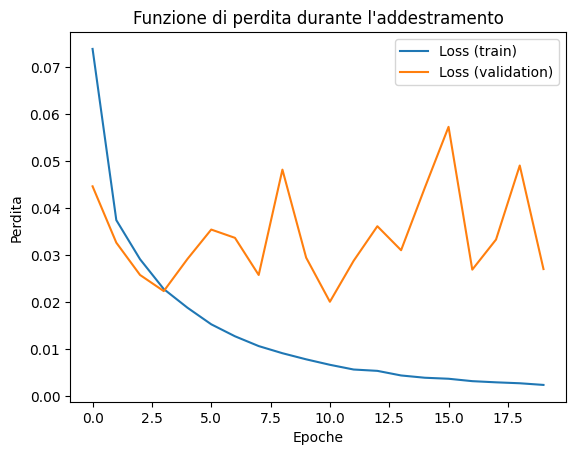

In [44]:
# Esempio di utilizzo per la colonna "Close"
print ('CLose')
model_close, history_close = modello_rnn(train_a_rnn_close, test_a_rnn_close, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_close.history['loss'], label='Loss (train)')
plt.plot(history_close.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step   
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Valutazione train
ME: 0.25701795520524845, RMSE: 0.6036561654127345, MAE: 0.3132269854456539, MPE: 2.2146079549829176, MAPE: 10.209576506139172
Valutazione test
ME: 1.4569807133429449, RMSE: 1.4688947621813306, MAE: 1.4569807133429449, MPE: 26.7114371802869, MAPE: 26.7114371802869


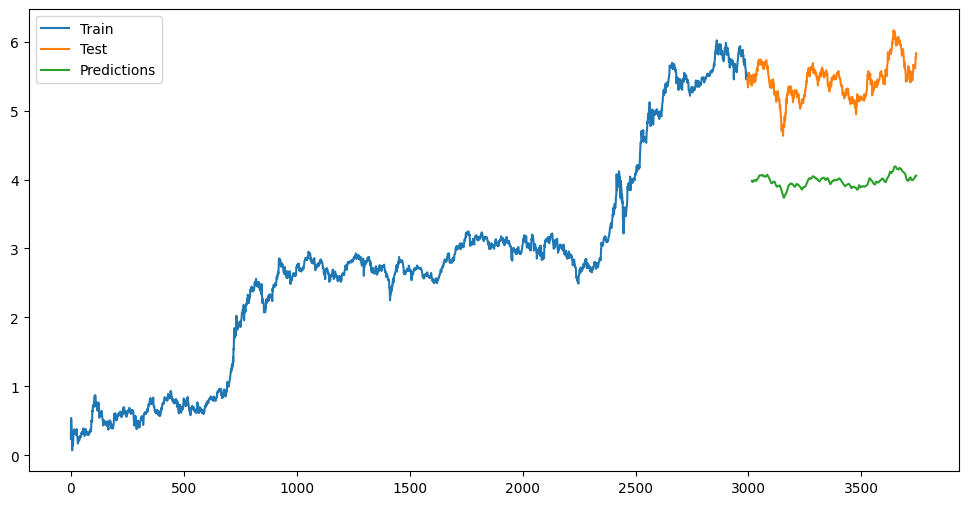

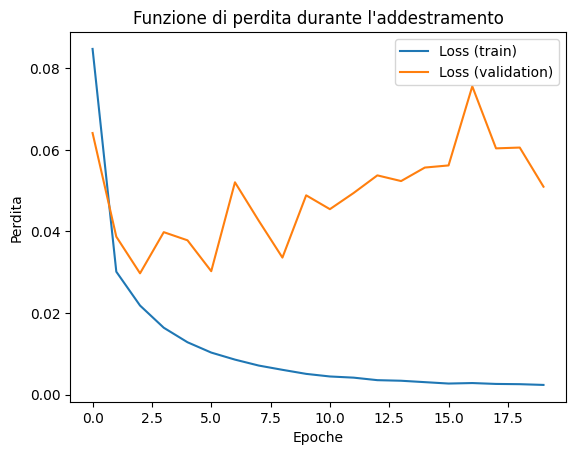

In [43]:
# Esempio di utilizzo per la colonna "Open"
print ('Open')
model_open, history_open = modello_rnn(train_a_rnn_open, test_a_rnn_open, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_open.history['loss'], label='Loss (train)')
plt.plot(history_open.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

In [45]:
#LSTM
def modello_lstm(train, test, seq_length=10, epochs=100, learning_rate=0.001, dropout_rate=0.2, l2_rate=0.001):
    # 1. Preparazione dei dati
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.reshape(-1, 1))
    scaled_test = scaler.transform(test.reshape(-1, 1))

    def create_sequences(data, seq_length):
        xs = []
        ys = []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(scaled_train, seq_length)
    X_test, y_test = create_sequences(scaled_test, seq_length)

    # 2. Costruzione e addestramento del modello LSTM con Dropout e L2
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(l2_rate)))  # Utilizza LSTM
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_rate)))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

    # Aggiungi EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stopping])

    # 3. Effettua le previsioni
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 4. Inverti la scala delle previsioni
    y_train_pred_original = scaler.inverse_transform(y_train_pred)
    y_test_pred_original = scaler.inverse_transform(y_test_pred)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)

    # 5. Calcola le metriche di valutazione
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    mae_train = mean_absolute_error(y_train_original, y_train_pred_original)
    mpe_train = np.mean((y_train_original - y_train_pred_original) / y_train_original) * 100
    mape_train = np.mean(np.abs((y_train_original - y_train_pred_original) / y_train_original)) * 100

    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
    mae_test = mean_absolute_error(y_test_original, y_test_pred_original)
    mpe_test = np.mean((y_test_original - y_test_pred_original) / y_test_original) * 100
    mape_test = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100

    # 6. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"ME: {np.mean(y_train_original - y_train_pred_original)}, RMSE: {rmse_train}, MAE: {mae_train}, MPE: {mpe_train}, MAPE: {mape_train}")
    print("Valutazione test")
    print(f"ME: {np.mean(y_test_original - y_test_pred_original)}, RMSE: {rmse_test}, MAE: {mae_test}, MPE: {mpe_test}, MAPE: {mape_test}")

    # 7. Visualizza le previsioni
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(train)), train, label='Train')
    plt.plot(range(len(train), len(train) + len(test)), test, label='Test')
    plt.plot(range(len(train) + seq_length, len(train) + len(test)), y_test_pred_original, label='Predictions')
    plt.legend()
    plt.show()

    return model, history

CLose


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Valutazione train
ME: 0.05582233458291886, RMSE: 0.14792758890300003, MAE: 0.11625742371699396, MPE: -0.3875502208254275, MAPE: 6.59086141539502
Valutazione test
ME: -0.04902275657252418, RMSE: 0.16953926863820826, MAE: 0.12547461566666251, MPE: -0.8437222186066051, MAPE: 2.2856853184523027


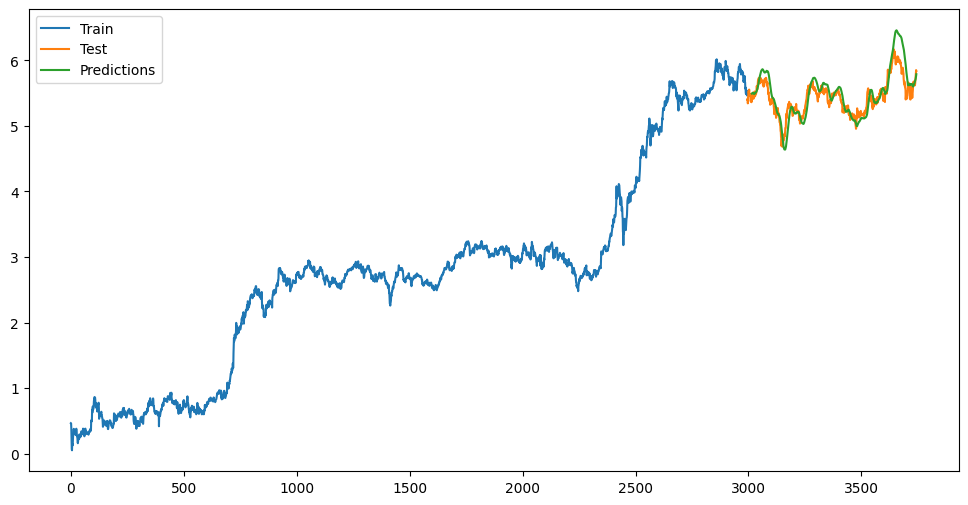

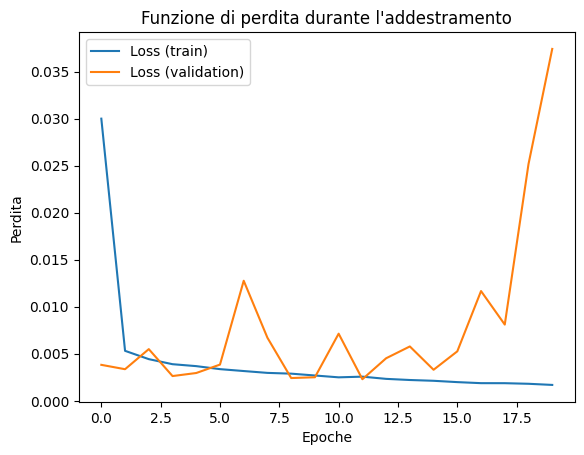

In [46]:
# Esempio di utilizzo per la colonna "Close"
print ('CLose')
model_close, history_close = modello_lstm(train_a_rnn_close, test_a_rnn_close, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_close.history['loss'], label='Loss (train)')
plt.plot(history_close.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()

Open


C:\Users\danie\Desktop\DANIELE\UNIVERSITA\laurea\magistrale\tesi\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Valutazione train
ME: 0.09107447030787534, RMSE: 0.33952185693598913, MAE: 0.3091826932153904, MPE: -13.160025365644218, MAPE: 25.950597518553586
Valutazione test
ME: 0.16322594176628472, RMSE: 0.22275248809704126, MAE: 0.19055448513279788, MPE: 3.057999003328332, MAPE: 3.5328539154964553


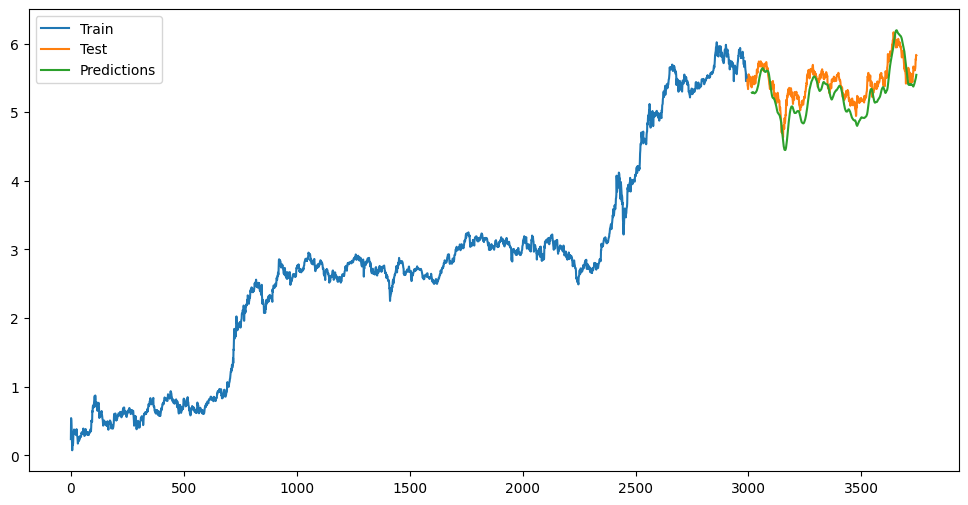

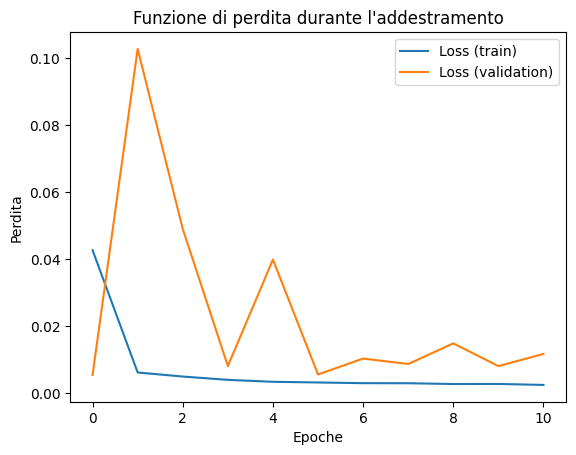

In [47]:
# Esempio di utilizzo per la colonna "Open"
print ('Open')
model_open, history_open = modello_lstm(train_a_rnn_open, test_a_rnn_open, seq_length=20, epochs=20, learning_rate=0.001)
# Visualizza la funzione di perdita
plt.plot(history_open.history['loss'], label='Loss (train)')
plt.plot(history_open.history['val_loss'], label='Loss (validation)')
plt.title('Funzione di perdita durante l\'addestramento')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend()
plt.show()